# Day 1 — Train / Validation / Test Splits

## Can we trust our model's test score?

In Week 3, we used a train/test split to evaluate our models.

But what happens when we repeatedly check the test set while choosing
a model or tuning its settings?

If our decisions are influenced by the test results, the test set is no
longer a truly unseen dataset. This can lead to overly optimistic
performance estimates.

Today, we introduce a third dataset: the validation set.

### Questions we will answer

- Why do we need a validation set?
- What is the role of each dataset?
- How can we create a 60/20/20 split?
- Why should the test set remain untouched until the very end?

Our goal is not only to create the split, but to understand why this
workflow produces a more reliable evaluation.

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("../../Week 1/tested.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## What does our dataset look like?

Before splitting the data, we first need to identify the target
variable and the features that will be used by the model.

In this dataset, `Survived` is our target.

The numerical columns will be used as features so that we can focus
on understanding the train/validation/test workflow.

In [3]:
numeric_df = df.select_dtypes(include=["number"])

X = numeric_df.drop("Survived", axis=1)
y = numeric_df["Survived"]

X = X.fillna(X.mean())

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (418, 6)
y shape: (418,)


## How should we divide the data?

A supervised learning workflow uses three datasets, each with a
different responsibility:

| Dataset | Purpose |
|---|---|
| Training | Learn the model's parameters |
| Validation | Compare models and tune decisions |
| Test | Provide the final unbiased evaluation |

We will use a 60/20/20 split:

- 60% Training
- 20% Validation
- 20% Test

The test set will remain untouched while we develop the model.

In [4]:
# Step 1: Hold out 20% for the final test set

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Why do we split the data twice?

The first split separates the final test set from the rest of the data.

We now have:

- 80% of the data available for development
- 20% completely held out for final testing

Next, we divide the remaining 80% into training and validation sets.

In [5]:
# Step 2: Split the remaining 80%
# into 60% training and 20% validation of the original dataset

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42
)

In [6]:
print("Training set   :", X_train.shape)
print("Validation set :", X_val.shape)
print("Test set       :", X_test.shape)

Training set   : (250, 6)
Validation set : (84, 6)
Test set       : (84, 6)


In [8]:
print("Train      :", len(X_train) / len(X) * 100, "%")
print("Validation :", len(X_val) / len(X) * 100, "%")
print("Test       :", len(X_test) / len(X) * 100, "%")

Train      : 59.80861244019139 %
Validation : 20.095693779904305 %
Test       : 20.095693779904305 %


## Which model setting should we choose?

The data is now separated into three independent sets.

However, we still need to make a modeling decision. A Decision Tree
can have different depths, and the depth controls how complex the
learned decision rules become.

A very shallow tree may be too simple and underfit the data, while a
very deep tree may memorize the training examples and overfit.

So instead of choosing the depth based on the test set, we will use
the validation set to compare different values.

### Question

Which tree depth gives us the best validation performance?

In [9]:
results = []

for depth in [2, 3, 4, 5, 6, 8, 10]:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    val_predictions = model.predict(X_val)
    val_accuracy = accuracy_score(y_val, val_predictions)

    results.append({
        "max_depth": depth,
        "validation_accuracy": val_accuracy
    })

results_df = pd.DataFrame(results)

results_df

,max_depth,validation_accuracy
0,2,0.678571
1,3,0.571429
2,4,0.654762
3,5,0.654762
4,6,0.607143
5,8,0.607143
6,10,0.642857


## What did the validation set tell us?

The validation results show that `max_depth=2` achieved the highest
validation accuracy at approximately 67.86%.

Therefore, we will select a Decision Tree with `max_depth=2`.

Notice that the test set has not been used to make this decision.
This is important because using the test set during tuning would
introduce information leakage and make our final evaluation less
trustworthy.

Now that the model choice is fixed, we can evaluate it on the test
set exactly once.

In [10]:
final_model = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

final_model.fit(X_train, y_train)

test_predictions = final_model.predict(X_test)

test_accuracy = accuracy_score(y_test, test_predictions)

print("Final Test Accuracy:", test_accuracy)

Final Test Accuracy: 0.6071428571428571


## Final Evaluation: What Did We Learn?

The validation set helped us select `max_depth=2`, which achieved the
highest validation accuracy of 67.86%.

After the model choice was finalized, we evaluated it on the test set
for the first time. The final test accuracy was 60.71%.

The lower test performance compared with validation performance shows
why the test set must remain untouched during model development.
Validation performance can help guide our decisions, but the test set
provides the final estimate of how the chosen model performs on unseen
data.

### Final takeaway

The key lesson is not simply the final accuracy. The important part is
the workflow:

1. Train the model using the training set.
2. Use the validation set to make development decisions.
3. Keep the test set untouched.
4. Evaluate the final model on the test set only after all decisions
   have been finalized.

This separation helps reduce evaluation bias and gives us a more
trustworthy estimate of model performance.

## How does tree depth affect validation performance?

The validation results show that model complexity does not automatically
lead to better performance.

A deeper tree can learn more detailed patterns, but it can also start
fitting noise in the training data.

The question is:

**Does increasing the tree depth actually improve validation performance?**

The following visualization helps us answer that question.

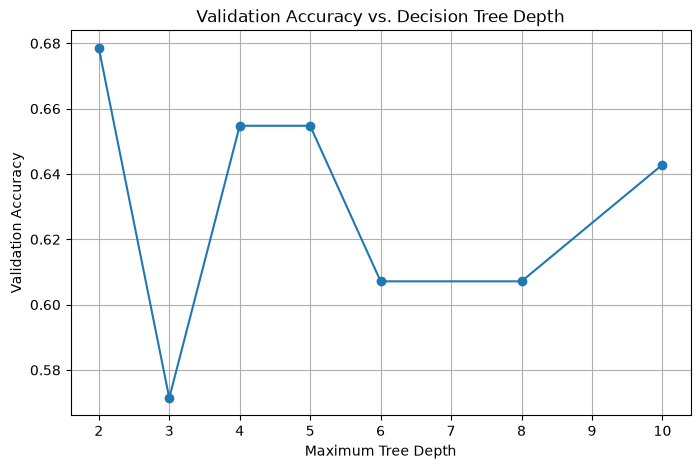

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    results_df["max_depth"],
    results_df["validation_accuracy"],
    marker="o"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs. Decision Tree Depth")
plt.grid(True)

plt.show()

### Interpretation

The visualization confirms that `max_depth=2` achieved the highest
validation accuracy among the tested values.

Increasing the depth did not consistently improve performance. This
shows why hyperparameters should be selected based on validation
performance rather than assuming that a more complex model is always
better.

For this dataset, the simpler tree provided the best validation result.